# SQL Business Queries
## Goal: Answer key business questions using SQL
## Method: SQLite database loaded from CSV outputs
## Dataset: IBM Telco Customer Churn — 7,032 customers

In [1]:
import pandas as pd
import sqlite3
import matplotlib.pyplot as plt
import seaborn as sns

sns.set_theme(style="whitegrid")

# Create SQLite database in memory
conn = sqlite3.connect(':memory:')

# Load CSV files into database tables
customers = pd.read_csv('../outputs/revenue_at_risk.csv')
clean = pd.read_csv('../data/telco_churn_cleaned.csv')

# Write to SQLite
customers.to_sql('customers', conn, index=False, if_exists='replace')
clean.to_sql('telco', conn, index=False, if_exists='replace')

print("Database created successfully")
print(f"customers table: {len(customers)} rows")
print(f"telco table: {len(clean)} rows")

Database created successfully
customers table: 7032 rows
telco table: 7032 rows


Query 1: Overall Churn Rate

In [2]:
query1 = """
SELECT 
    COUNT(*) as Total_Customers,
    SUM(CASE WHEN Churn = 'Yes' THEN 1 ELSE 0 END) as Churned_Customers,
    ROUND(
        SUM(CASE WHEN Churn = 'Yes' THEN 1 ELSE 0 END) * 100.0 / COUNT(*), 2
    ) as Churn_Rate_Pct
FROM telco
"""

result1 = pd.read_sql_query(query1, conn)
print("Query 1 — Overall Churn Rate:")
print(result1.to_string(index=False))

Query 1 — Overall Churn Rate:
 Total_Customers  Churned_Customers  Churn_Rate_Pct
            7032               1869           26.58


 Query 2: Churn Rate by Contract Type

In [3]:
query2 = """
SELECT 
    Contract,
    COUNT(*) as Total_Customers,
    SUM(CASE WHEN Churn = 'Yes' THEN 1 ELSE 0 END) as Churned,
    ROUND(
        SUM(CASE WHEN Churn = 'Yes' THEN 1 ELSE 0 END) * 100.0 / COUNT(*), 2
    ) as Churn_Rate_Pct
FROM telco
GROUP BY Contract
ORDER BY Churn_Rate_Pct DESC
"""

result2 = pd.read_sql_query(query2, conn)
print("Query 2 — Churn Rate by Contract Type:")
print(result2.to_string(index=False))

Query 2 — Churn Rate by Contract Type:
      Contract  Total_Customers  Churned  Churn_Rate_Pct
Month-to-month             3875     1655           42.71
      One year             1472      166           11.28
      Two year             1685       48            2.85


Query 3: Top 10 Customers by CLV

In [4]:
query3 = """
SELECT 
    customerID,
    tenure,
    MonthlyCharges,
    ROUND(CLV_Enhanced, 2) as CLV,
    CLV_Tier,
    Segment,
    Risk_Label,
    Retention_Strategy
FROM customers
ORDER BY CLV_Enhanced DESC
LIMIT 10
"""

result3 = pd.read_sql_query(query3, conn)
print("Query 3 — Top 10 Customers by CLV:")
print(result3.to_string(index=False))

Query 3 — Top 10 Customers by CLV:
customerID  tenure  MonthlyCharges     CLV CLV_Tier   Segment Risk_Label Retention_Strategy
2889-FPWRM      72          117.80 8684.80  Premium Champions   Low Risk   No Action Needed
7569-NMZYQ      72          118.75 8672.45  Premium Champions   Low Risk   No Action Needed
9739-JLPQJ      72          117.50 8670.10  Premium Champions   Low Risk   No Action Needed
9788-HNGUT      72          116.95 8594.40  Premium Champions   Low Risk   No Action Needed
8879-XUAHX      71          116.25 8564.75  Premium Champions   Low Risk   No Action Needed
9924-JPRMC      72          118.20 8547.15  Premium Champions   Low Risk   No Action Needed
0675-NCDYU      72          116.40 8543.25  Premium Champions   Low Risk   No Action Needed
6650-BWFRT      72          117.15 8529.50  Premium Champions   Low Risk   No Action Needed
0164-APGRB      72          114.90 8496.70  Premium Champions   Low Risk   No Action Needed
1488-PBLJN      72          116.85 8477.70  P

Query 4: Revenue at Risk by Segment

In [5]:
query4 = """
SELECT 
    Segment,
    COUNT(*) as Customers,
    ROUND(SUM(Revenue_at_Risk), 2) as Total_Revenue_at_Risk,
    ROUND(AVG(Revenue_at_Risk), 2) as Avg_Revenue_at_Risk,
    ROUND(AVG(Churn_Probability) * 100, 2) as Avg_Churn_Prob_Pct
FROM customers
GROUP BY Segment
ORDER BY Total_Revenue_at_Risk DESC
"""

result4 = pd.read_sql_query(query4, conn)
print("Query 4 — Revenue at Risk by Segment:")
print(result4.to_string(index=False))

Query 4 — Revenue at Risk by Segment:
        Segment  Customers  Total_Revenue_at_Risk  Avg_Revenue_at_Risk  Avg_Churn_Prob_Pct
      Champions       1962             2701319.88              1376.82               31.84
Loyal Customers       1361              803049.90               590.04               44.86
        At Risk       1808              322975.38               178.64               44.41
       Inactive       1901               58884.17                30.98               40.38


Query 5: High Risk Customer Count by Segment

In [6]:
query5 = """
SELECT 
    Segment,
    Risk_Label,
    COUNT(*) as Customers,
    ROUND(SUM(Revenue_at_Risk), 2) as Total_Revenue_at_Risk
FROM customers
WHERE Risk_Label = 'High Risk'
GROUP BY Segment, Risk_Label
ORDER BY Total_Revenue_at_Risk DESC
"""

result5 = pd.read_sql_query(query5, conn)
print("Query 5 — High Risk Customers by Segment:")
print(result5.to_string(index=False))

Query 5 — High Risk Customers by Segment:
        Segment Risk_Label  Customers  Total_Revenue_at_Risk
      Champions  High Risk        237              548735.45
Loyal Customers  High Risk        407              299736.09
        At Risk  High Risk        611              134531.10
       Inactive  High Risk        476               19720.64


Query 6: Avg Monthly Charges by Churn

In [7]:
query6 = """
SELECT 
    Churn,
    COUNT(*) as Customers,
    ROUND(AVG(MonthlyCharges), 2) as Avg_Monthly_Charges,
    ROUND(AVG(tenure), 2) as Avg_Tenure_Months,
    ROUND(AVG(TotalCharges), 2) as Avg_Total_Charges
FROM telco
GROUP BY Churn
ORDER BY Churn DESC
"""

result6 = pd.read_sql_query(query6, conn)
print("Query 6 — Avg Monthly Charges by Churn:")
print(result6.to_string(index=False))

Query 6 — Avg Monthly Charges by Churn:
Churn  Customers  Avg_Monthly_Charges  Avg_Tenure_Months  Avg_Total_Charges
  Yes       1869                74.44              17.98            1531.80
   No       5163                61.31              37.65            2555.34


Query 7: Retention Strategy Distribution

In [8]:
query7 = """
SELECT 
    Retention_Strategy,
    COUNT(*) as Customers,
    ROUND(SUM(Revenue_at_Risk), 2) as Total_Revenue_at_Risk,
    ROUND(AVG(Churn_Probability) * 100, 2) as Avg_Churn_Prob_Pct
FROM customers
GROUP BY Retention_Strategy
ORDER BY Total_Revenue_at_Risk DESC
"""

result7 = pd.read_sql_query(query7, conn)
print("Query 7 — Retention Strategy Distribution:")
print(result7.to_string(index=False))

Query 7 — Retention Strategy Distribution:
           Retention_Strategy  Customers  Total_Revenue_at_Risk  Avg_Churn_Prob_Pct
               Loyalty Reward        859             1609210.94               55.67
             No Action Needed       3765             1197928.04               13.82
Personal Relationship Manager        463              795622.22               78.39
               Discount Offer        492              171992.44               83.27
                 SMS Reminder        677               76367.07               56.40
               Email Campaign        776               35108.62               84.11


Query 8: Priority Customer Summary

In [9]:
query8 = """
SELECT 
    Priority,
    COUNT(*) as Customers,
    ROUND(SUM(Revenue_at_Risk), 2) as Total_Revenue_at_Risk,
    ROUND(AVG(Revenue_at_Risk), 2) as Avg_Revenue_at_Risk,
    ROUND(AVG(Churn_Probability) * 100, 2) as Avg_Churn_Prob_Pct
FROM customers
GROUP BY Priority
ORDER BY 
    CASE Priority
        WHEN 'Critical' THEN 1
        WHEN 'High' THEN 2
        WHEN 'Medium' THEN 3
        WHEN 'Low' THEN 4
    END
"""

result8 = pd.read_sql_query(query8, conn)
print("Query 8 — Priority Customer Summary:")
print(result8.to_string(index=False))

Query 8 — Priority Customer Summary:
Priority  Customers  Total_Revenue_at_Risk  Avg_Revenue_at_Risk  Avg_Churn_Prob_Pct
Critical        463              795622.22              1718.41               78.39
    High       2127             1816312.00               853.93               72.43
  Medium        677               76367.07               112.80               56.40
     Low       3765             1197928.04               318.17               13.82


Query 9: Top 10 Customers by Revenue at Risk

In [10]:
query9 = """
SELECT 
    customerID,
    ROUND(Churn_Probability * 100, 2) as Churn_Prob_Pct,
    Risk_Label,
    Priority,
    ROUND(CLV_Enhanced, 2) as CLV,
    ROUND(Revenue_at_Risk, 2) as Revenue_at_Risk,
    Retention_Strategy
FROM customers
ORDER BY Revenue_at_Risk DESC
LIMIT 10
"""

result9 = pd.read_sql_query(query9, conn)
print("Query 9 — Top 10 Customers by Revenue at Risk:")
print(result9.to_string(index=False))

Query 9 — Top 10 Customers by Revenue at Risk:
customerID  Churn_Prob_Pct  Risk_Label Priority     CLV  Revenue_at_Risk            Retention_Strategy
9090-SGQXL           82.19   High Risk Critical 7299.65          5999.58 Personal Relationship Manager
4550-VBOFE           81.50   High Risk Critical 7101.50          5787.72 Personal Relationship Manager
4282-MSACW           69.72 Medium Risk     High 8035.95          5602.66                Loyalty Reward
0748-RDGGM           73.19   High Risk Critical 7534.65          5514.61 Personal Relationship Manager
3838-OZURD           74.76   High Risk Critical 7133.25          5332.82 Personal Relationship Manager
1444-VVSGW           66.62 Medium Risk     High 7968.85          5308.85                Loyalty Reward
1469-LBJQJ           75.29   High Risk Critical 6936.85          5222.75 Personal Relationship Manager
3571-RFHAR           74.35   High Risk Critical 6941.20          5160.78 Personal Relationship Manager
1984-FCOWB           66.71

Query 10: Churn Rate by CLV Tier

In [11]:
query10 = """
SELECT 
    CLV_Tier,
    COUNT(*) as Total_Customers,
    SUM(CASE WHEN Churn = 'Yes' THEN 1 ELSE 0 END) as Churned,
    ROUND(
        SUM(CASE WHEN Churn = 'Yes' THEN 1 ELSE 0 END) * 100.0 / COUNT(*), 2
    ) as Churn_Rate_Pct,
    ROUND(AVG(Revenue_at_Risk), 2) as Avg_Revenue_at_Risk
FROM customers
GROUP BY CLV_Tier
ORDER BY Churn_Rate_Pct DESC
"""

result10 = pd.read_sql_query(query10, conn)
print("Query 10 — Churn Rate by CLV Tier:")
print(result10.to_string(index=False))

Query 10 — Churn Rate by CLV Tier:
    CLV_Tier  Total_Customers  Churned  Churn_Rate_Pct  Avg_Revenue_at_Risk
   Low Value             1758      713           40.56                30.36
Medium Value             1758      451           25.65               164.93
  High Value             1758      440           25.03               634.17
     Premium             1758      265           15.07              1381.13


 Summary Visualization

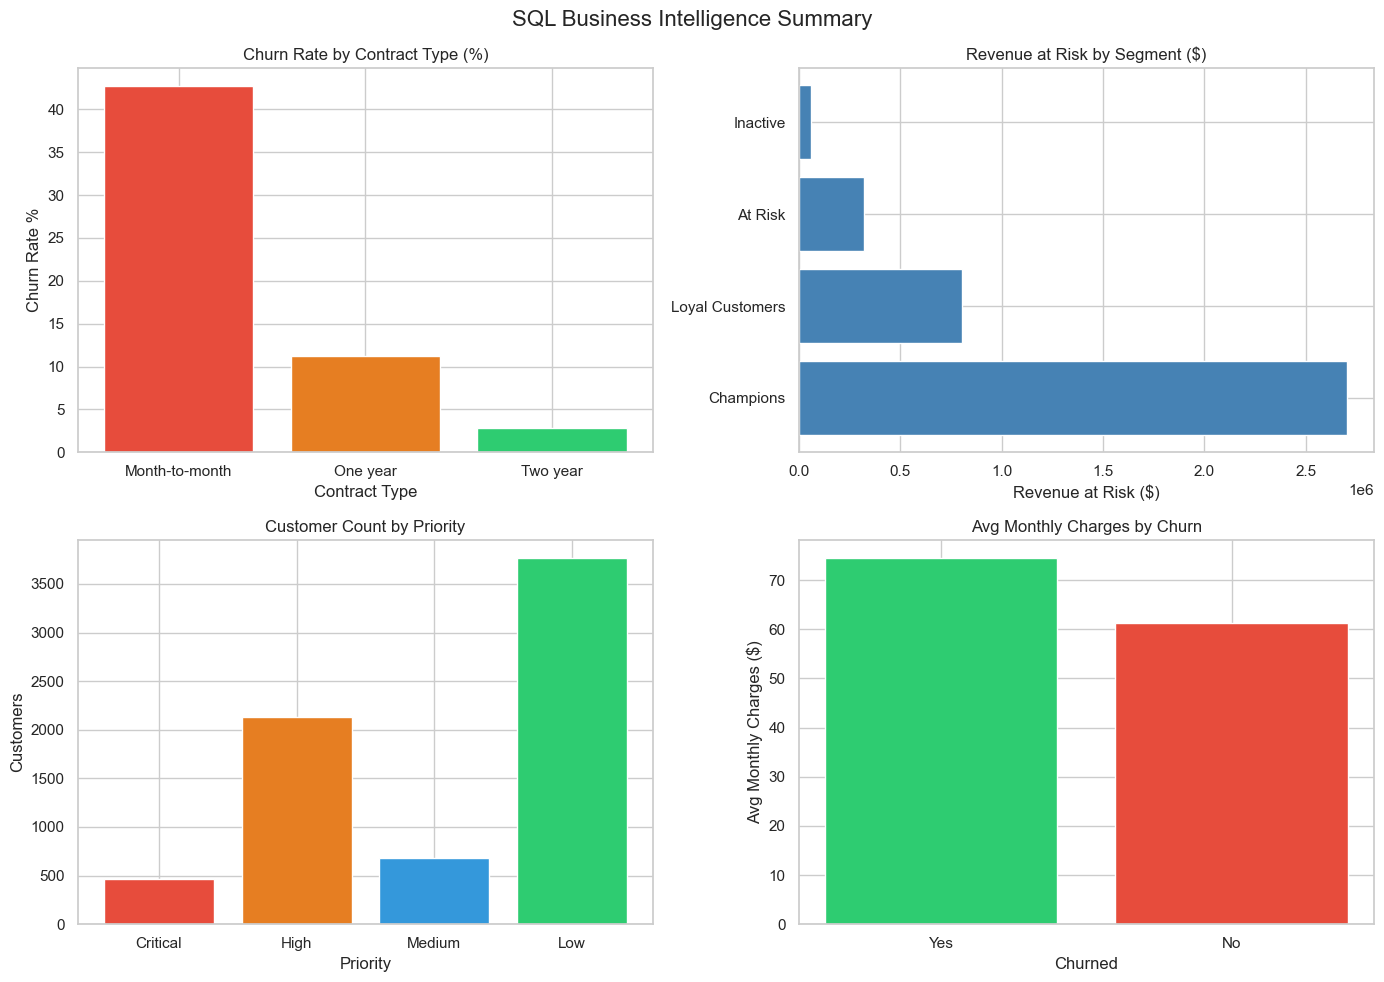

SQL summary chart saved


In [12]:
fig, axes = plt.subplots(2, 2, figsize=(14, 10))

# Chart 1 — Churn Rate by Contract Type
axes[0,0].bar(result2['Contract'], result2['Churn_Rate_Pct'],
              color=['#e74c3c','#e67e22','#2ecc71'], edgecolor='white')
axes[0,0].set_title('Churn Rate by Contract Type (%)')
axes[0,0].set_xlabel('Contract Type')
axes[0,0].set_ylabel('Churn Rate %')

# Chart 2 — Revenue at Risk by Segment
axes[0,1].barh(result4['Segment'], result4['Total_Revenue_at_Risk'],
               color='steelblue', edgecolor='white')
axes[0,1].set_title('Revenue at Risk by Segment ($)')
axes[0,1].set_xlabel('Revenue at Risk ($)')

# Chart 3 — Priority Distribution
axes[1,0].bar(result8['Priority'], result8['Customers'],
              color=['#e74c3c','#e67e22','#3498db','#2ecc71'],
              edgecolor='white')
axes[1,0].set_title('Customer Count by Priority')
axes[1,0].set_xlabel('Priority')
axes[1,0].set_ylabel('Customers')

# Chart 4 — Avg Monthly Charges by Churn
axes[1,1].bar(result6['Churn'], result6['Avg_Monthly_Charges'],
              color=['#2ecc71','#e74c3c'], edgecolor='white')
axes[1,1].set_title('Avg Monthly Charges by Churn')
axes[1,1].set_xlabel('Churned')
axes[1,1].set_ylabel('Avg Monthly Charges ($)')

plt.suptitle('SQL Business Intelligence Summary', fontsize=16)
plt.tight_layout()
plt.savefig('../outputs/sql_summary.png', dpi=150, bbox_inches='tight')
plt.show()
print("SQL summary chart saved")